In [11]:
import joblib 
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix


In [12]:
df = pd.read_csv('../data/creditcard_processed.csv')
original_df = pd.read_csv('../data/german_credit_data.csv')

X = df.drop('Class', axis=1)
y = df['Class']


# 2. Define the Model
iso_forest = IsolationForest(contamination=0.0017, random_state=42, n_estimators=100)


# 3. Train (Unsupervised 
print("Training the Isolation Forest model...")
iso_forest.fit(X)

# 4. Predict
preds = iso_forest.predict(X)

# 5. Map Predictions 
preds_mapped = [1 if x == -1 else 0 for x in preds]

# 6. Evaluation
print("\n--- Model Evaluation ---")
print(classification_report(y, preds_mapped))

# Confusion Matrix
cm = confusion_matrix(y, preds_mapped)
print("Confusion Matrix", cm)
print(f"Legit Caught: {cm[0][0]} | False Alarms: {cm[0][1]}")
print(f"Missed Fraud: {cm[1][0]} | Caught Fraud: {cm[1][1]}")

Training the Isolation Forest model...

--- Model Evaluation ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    284315
           1       0.32      0.31      0.31       492

    accuracy                           1.00    284807
   macro avg       0.66      0.65      0.66    284807
weighted avg       1.00      1.00      1.00    284807

Confusion Matrix [[283983    332]
 [   339    153]]
Legit Caught: 283983 | False Alarms: 332
Missed Fraud: 339 | Caught Fraud: 153


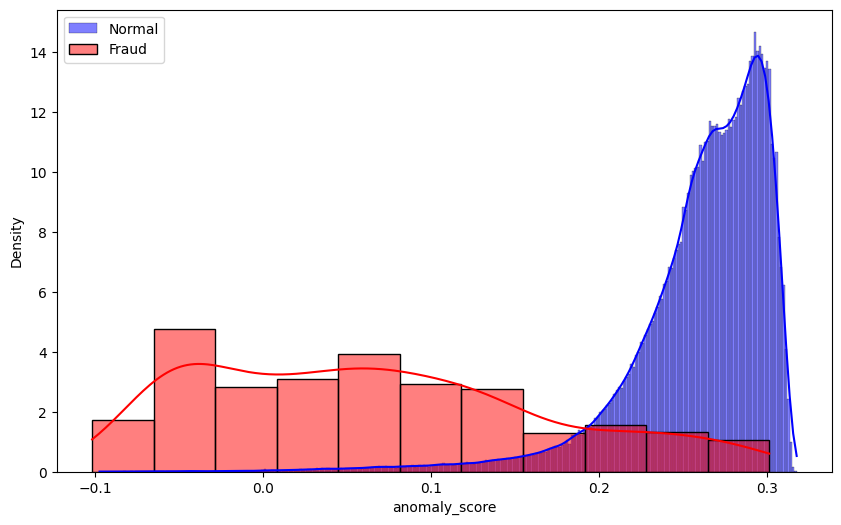

In [4]:
df['anomaly_score'] = iso_forest.decision_function(X)
df['prediction'] = preds_mapped

# --- PLOT 1: Score Distribution (The "Separation")
plt.figure(figsize=(10,6))
sns.histplot(df[df['Class'] == 0]['anomaly_score'], color='blue', label="Normal", kde=True,stat='density')
sns.histplot(df[df['Class'] == 1]['anomaly_score'], color='red', label="Fraud", kde=True,stat='density')
plt.legend()
plt.show()


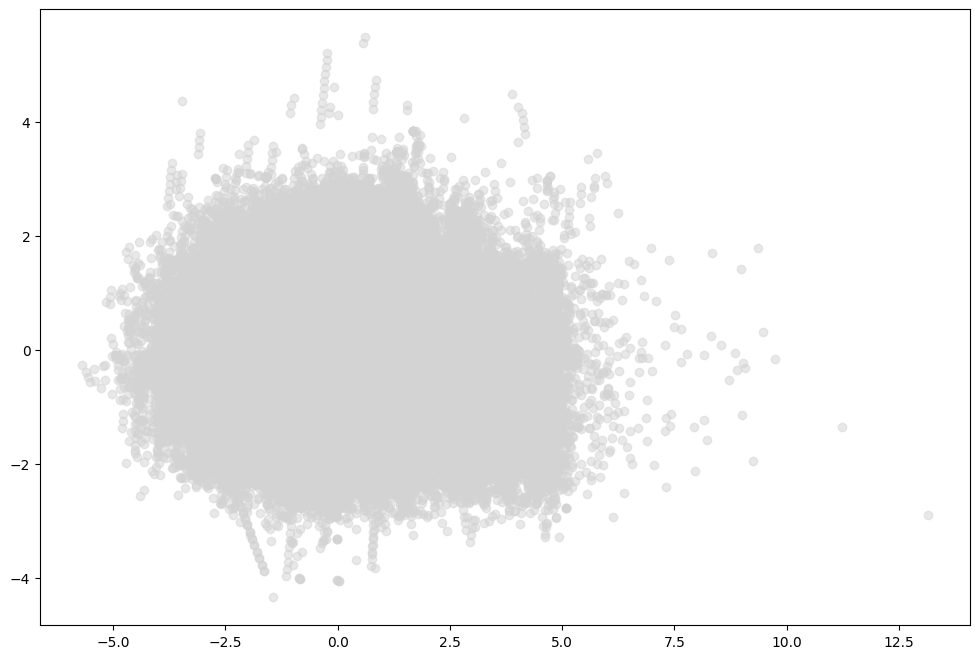

In [5]:
# --- PLOT 2: The "Kill Zone"
# We pick V4 and V11 because they are often highly correlated with fraud in this dataset
plt.figure(figsize=(12, 8))
# Plot True Negatives (Normal stuff we ignored) - Light Grey
plt.scatter(df[(df['Class']==0) & (df['prediction']==0)]['V4'], 
            df[(df['Class']==0) & (df['prediction']==0)]['V11'], 
            c='lightgrey', alpha=0.5, label='Normal (Ignored)')

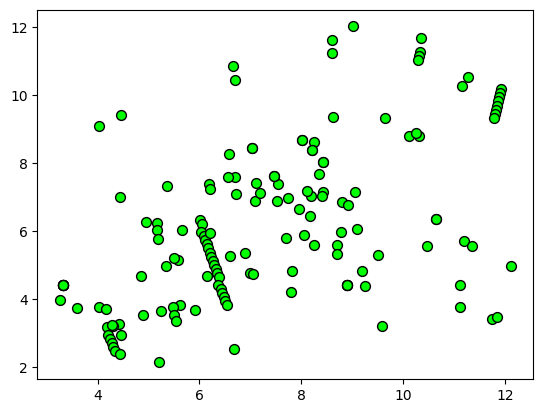

In [6]:
# Plot True Positives (Frauds we CAUGHT) - Bright Green
plt.scatter(df[(df['Class']==1) & (df['prediction']==1)]['V4'], 
            df[(df['Class']==1) & (df['prediction']==1)]['V11'], 
            c='lime', s=50, edgecolors='black', label='Caught Fraud (TP)')

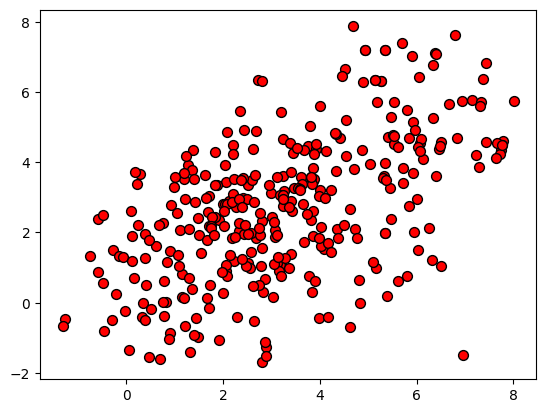

In [7]:
# Plot False Negatives (Frauds we MISSED) - Red
plt.scatter(df[(df['Class']==1) & (df['prediction']==0)]['V4'], 
            df[(df['Class']==1) & (df['prediction']==0)]['V11'], 

            c='red', s=50, edgecolors='black', label='Missed Fraud (FN)')

In [13]:
# Get raw scores
raw_scores = iso_forest.decision_function(X)

scaler = RobustScaler()
scaler.fit(original_df[['Amount']])
print("✅ Scaler re-fitted.")

# Invert them: Multiply by -1 so Anomalies become the BIG numbers
inverted_scores = raw_scores * -1

# Scale them to 0-100 range
min_max = MinMaxScaler(feature_range=(0,100))
df['risk_score'] = min_max.fit_transform(inverted_scores.reshape(-1,1))


# Check the results
print("--- Risk Score Analysis ---")
print("Avg Risk of LEGIT transactions:", df[df['Class']==0]['risk_score'].mean())
print("Avg Risk of FRAUD transactions:", df[df['Class']==1]['risk_score'].mean())

os.makedirs('../models', exist_ok=True)

joblib.dump(iso_forest, '../models/iso_forest.joblib')
joblib.dump(scaler, '../models/robust_scaler.joblib') # The one from Preprocessing
joblib.dump(min_max, '../models/score_scaler.joblib') # To scale new scores in the App
joblib.dump(X.columns.tolist(), '../models/model_columns.joblib') # Column names

print("\n✅ Models saved to ../models/")
print("READY FOR APP DEPLOYMENT.")


✅ Scaler re-fitted.
--- Risk Score Analysis ---
Avg Risk of LEGIT transactions: 13.71121277055961
Avg Risk of FRAUD transactions: 60.20278141415332

✅ Models saved to ../models/
READY FOR APP DEPLOYMENT.
